<div class="alert alert-block alert-info"> 
<h1><center> TSKS35: Information and Communications Engineering </center></h1>
<br>
<h2><center><font size="5">Laboratory Exercise 2: Frequency analysis and sampling</font></center></h2>
</div>




Communication signals and systems can be characterised in both time and the frequency domains. Frequency domain representations are particularly useful when analyzing linear systems (a large number of communication channels can be modeled closely by linear systems) as the system behavior and signal transformations are more convenient and intuitive when working in the frequency domain. 

In this session, we will revisit the frequency domain analysis of signals, power- and energy-type signals, the Sampling Theorem, bandpass signals, and lowpass representation of bandpass signals.

__NOTE:__ Revisit sections 2.3, 2.4, and 2.5 of the course book before the session.


### Power and Energy 

The energy content of a signal $x(t)$, denoted by $E_x$, is defined as

<center>$E_x=\int_{-\infty}^{\infty} |x(t)|^2 dt$<center>
    
and the power content of a signal is

<center>$P_x=\underset{T\rightarrow \infty}{\lim}\int_{-T/2}^{T/2} |x(t)|^2 dt$<center>

<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 1: Power- and energy-type signals</span></font>
    
Consider the signal generated in the code snippet below.
    
1. Write a program to calculate the energy and power of the signal. 
2. Calculate the (time-average) autocorrelation function of the signal and plot it.
3. Calculate the energy/power spectrum and plot it.

__Hint:__ Check numpy.correlate function [here](https://numpy.org/doc/stable/reference/generated/numpy.correlate.html) and fourier transforms numpy.fft.fft [here](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html) 

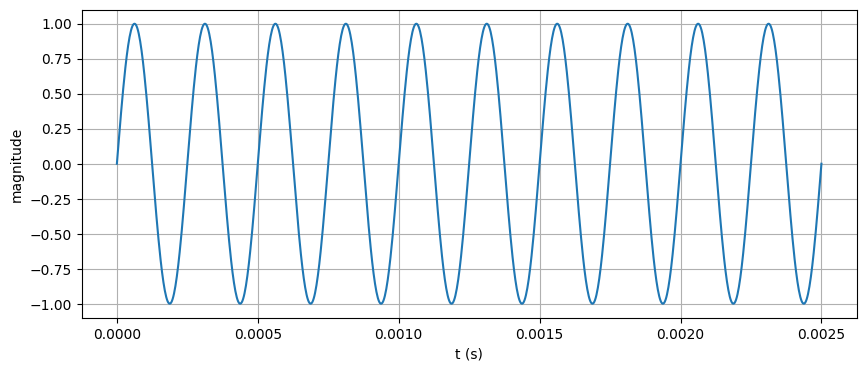

In [1]:
import numpy as np
import matplotlib.pyplot as plt
f = 4000  # frequency in Hz
T=1/f
t = np.linspace(0, 10*T, 1000)
s = np.sin(2 * np.pi * f * t)
plt.figure(figsize=(10, 4))
plt.plot(t, s)
plt.xlabel("t (s)")
plt.ylabel("magnitude")
plt.grid(True)
plt.show()

Energy of the signal: 499.50000000000006
Power of the signal: 0.0


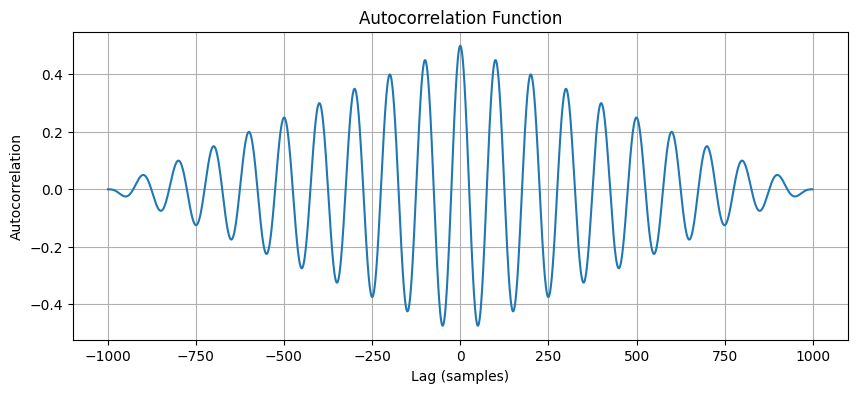

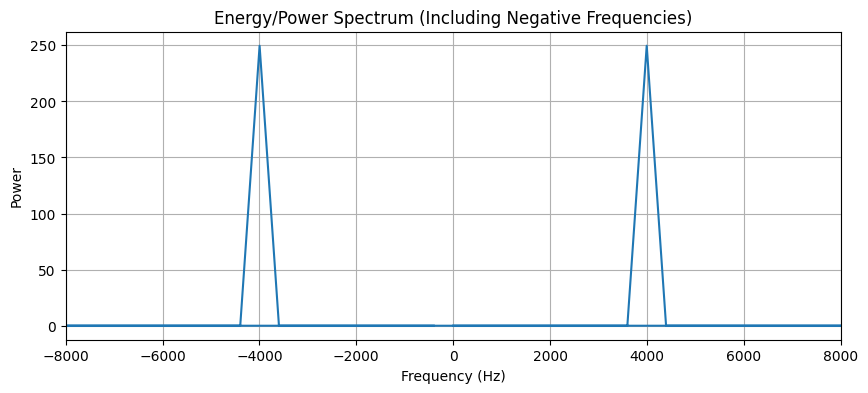

In [16]:
f = 4000  # frequency in Hz
T = 1 / f  # period of the signal
t = np.linspace(0, 10 * T, 1000)  # time vector, covering 10 periods
signal = np.sin(2 * np.pi * f * t)  # generate the signal

# 1. Calculate the energy of the signal
energy = np.sum(np.abs(signal) ** 2)

# 2. Calculate the power of the signal (time-averaged)
power = energy /np.inf

print("Energy of the signal:", energy)
print("Power of the signal:", power)

# 3. Calculate the autocorrelation function
autocorrelation = np.correlate(signal, signal, mode='full') / len(signal)

# Create an array for lag values (used in autocorrelation plot)
lags = np.arange(-len(signal) + 1, len(signal))

# Plot the autocorrelation function
plt.figure(figsize=(10, 4))
plt.plot(lags, autocorrelation)
plt.title("Autocorrelation Function")
plt.xlabel("Lag (samples)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()
# 4. Calculate the energy/power spectrum using FFT
spectrum = np.fft.fft(signal)
frequency = np.fft.fftfreq(len(signal), d=t[1] - t[0])  # Frequency axis

# Energy spectrum (use the full spectrum, including negative frequencies)
spectrum_power = np.abs(spectrum) ** 2 / len(signal)

# Plot the energy/power spectrum including both negative and positive frequencies
plt.figure(figsize=(10, 4))
plt.plot(frequency, spectrum_power)
plt.title("Energy/Power Spectrum (Including Negative Frequencies)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim([-f * 2, f * 2])  # Set the x-axis to show both positive and negative frequencies
plt.grid(True)
plt.show()

### Sampling Theorem

Let the signal $x(t)$ be bandlimited with bandwidth $W$; i.e., $X(f)=0$ for $|f|\geq W$. Let $x(t)$ be sampled at multiples of some basic sampling interval $T_s$, where $T_s\leq\tfrac{1}{2W}$.     Then, it is possible to reconstruct the original signal $x(t)$ back from the sampled values by the reconstruction filter, which is an ideal low pass filter with bandwith $W'$, given by
    \begin{align}
        \nonumber x(t)=\sum_{n=-\infty}^{\infty} 2W' T_s x(n T_s) \mathrm{sinc}\left[2W' (t-nT_s)\right],
    \end{align}
     where $W'$ is any arbitrary number that satisfies $W\leq W'\leq\dfrac{1}{T_s}-W$ and $f_s=2W$ is the minimum sampling rate (Nyquist sampling rate) at which no aliasing occurs.

The code snippet below illustrates the process of sampling the monochromatic signal $x(t)$ with spectrum $X(f)$

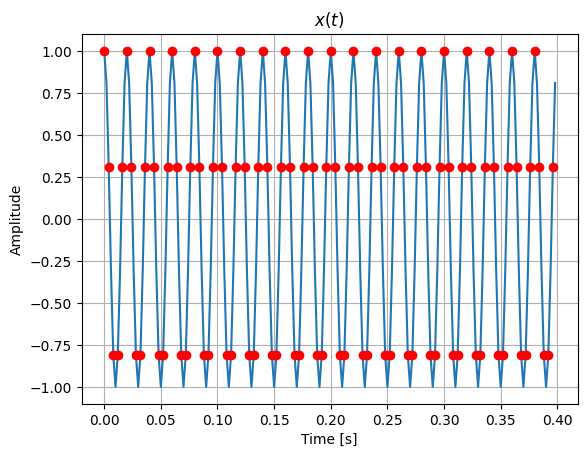

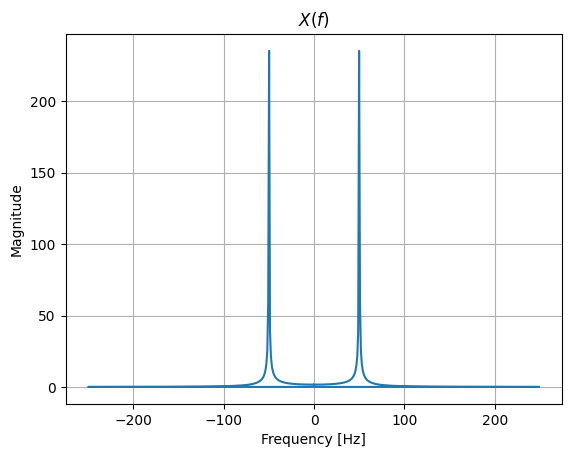

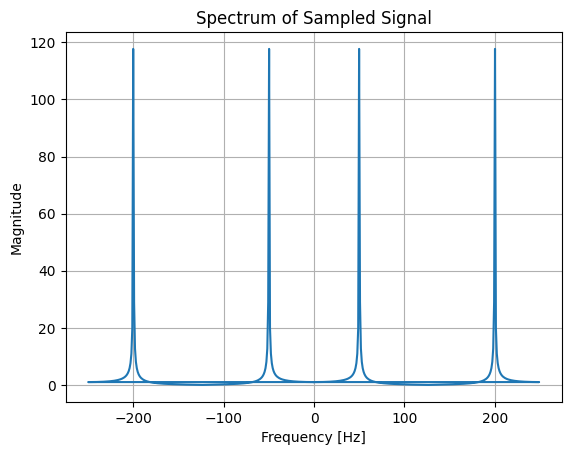

In [14]:
##Example

f1 = 50
f=10*f1
t = np.arange(0, 1+2/f, 1/f)


##Time domain signal
time_domain_signal =  np.cos(2*np.pi*f1*t)

##Frequency domain signal
frequency_domain_signal = np.fft.fft(time_domain_signal)
frequencies1 = np.fft.fftfreq(len(frequency_domain_signal), 1/f)

##Generate sampled signal
impulse_train = np.zeros_like(t)
impulse_train[::2] = 1
sampled_signal=impulse_train*time_domain_signal

#plt.stem(t, impulse_train*time_domain_signal,'r', markerfmt='ro')

##Frequency domain sampled signal
frequency_domain_sampled_signal = np.fft.fft(sampled_signal)
frequencies2 = np.fft.fftfreq(len(frequency_domain_sampled_signal),1/f)

##Plot of the time domain signal
sl = slice(200)
plt.plot(t[sl], time_domain_signal[sl])
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('$x(t)$')
plt.grid(True)

##Plot of the sampled signal
sampled_signal_plot=sampled_signal.copy()
sampled_signal_plot[sampled_signal_plot==0 ] = np.nan
plt.plot(t[sl], sampled_signal_plot[sl],'ro')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('$x(t)$')
plt.grid(True)
plt.show()

##Plot of the spectrum of original signal
plt.plot(frequencies1, np.abs(frequency_domain_signal))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('$X(f)$')
plt.grid(True)
plt.show()

##Plot of the spectrum of sampled signal
plt.plot(frequencies2, np.abs(frequency_domain_sampled_signal))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Spectrum of Sampled Signal')
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 2: Sampling</span></font>
    
Consider the example above.
    
1. Write a program to the sampling of a two-tone signal, with frequencies $f_1=10$ Hz and $f_2=60$ Hz. 
2. Verify how to change the sampling rate and observe the results.

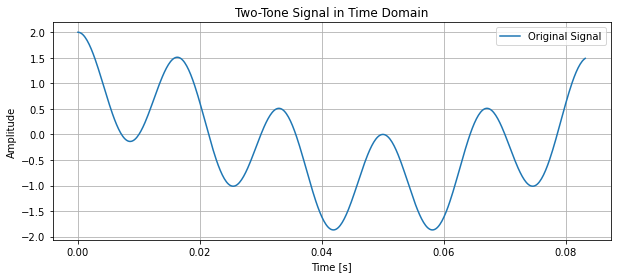

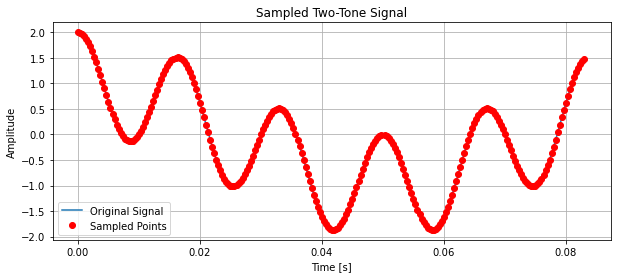

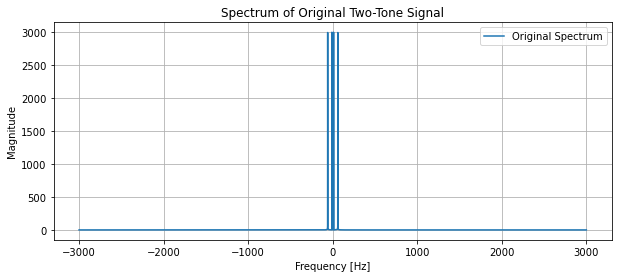

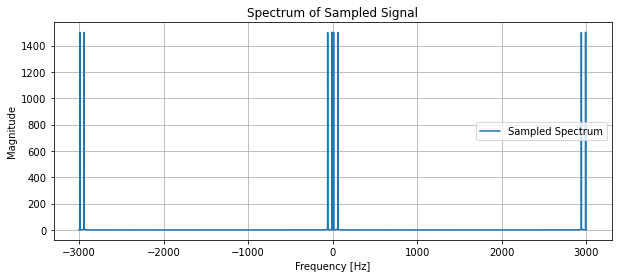

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Frequencies of the two-tone signal
f1 = 10  # Frequency of the first tone in Hz
f2 = 60  # Frequency of the second tone in Hz
# Sampling frequency and time vector
sampling_rate = 100 * f2  # Oversample with 10 times the highest frequency
t = np.arange(0, 1 + 2/sampling_rate, 1/sampling_rate)  # Time vector
# Two-tone time-domain signal
time_domain_signal = np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)
# Frequency domain of the original signal
frequency_domain_signal = np.fft.fft(time_domain_signal)
frequencies = np.fft.fftfreq(len(frequency_domain_signal), 1/sampling_rate)
# Generate sampled signal using an impulse train
sampling_interval = 2  # Adjust sampling interval (1/sample interval = sampling rate)
impulse_train = np.zeros_like(t)
impulse_train[::sampling_interval] = 1
sampled_signal = impulse_train * time_domain_signal
# Frequency domain of the sampled signal
frequency_domain_sampled_signal = np.fft.fft(sampled_signal)
frequencies_sampled = np.fft.fftfreq(len(frequency_domain_sampled_signal), 1/sampling_rate)
# Plot original time-domain signal
plt.figure(figsize=(10, 4))
sl = slice(500)  # Show a portion for clarity
plt.plot(t[sl], time_domain_signal[sl], label='Original Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Two-Tone Signal in Time Domain')
plt.grid(True)
plt.legend()
plt.show()
# Plot sampled signal
plt.figure(figsize=(10, 4))
sampled_signal_plot = sampled_signal.copy()
sampled_signal_plot[sampled_signal_plot == 0] = np.nan  # Show sampled points only
plt.plot(t[sl], time_domain_signal[sl], label='Original Signal')
plt.plot(t[sl], sampled_signal_plot[sl], 'ro', label='Sampled Points')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Sampled Two-Tone Signal')
plt.grid(True)
plt.legend()
plt.show()
# Plot spectrum of original signal
plt.figure(figsize=(10, 4))
plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(np.abs(frequency_domain_signal)), label='Original Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Spectrum of Original Two-Tone Signal')
plt.grid(True)
plt.legend()
plt.show()
# Plot spectrum of sampled signal
plt.figure(figsize=(10, 4))
plt.plot(np.fft.fftshift(frequencies_sampled), np.fft.fftshift(np.abs(frequency_domain_sampled_signal)), label='Sampled Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Spectrum of Sampled Signal')
plt.grid(True)
plt.legend()
plt.show()

### Bandpass signals and lowpass representation

A bandpass or narrowband signal is a signal $x(t)$ whose frequency domain representation $X(f)$ is nonzero for frequencies in a usually samll neighborhood of some high frequency $f_0$; i.e. $X(f)=0$ for $|f-f_0|\geq W$, $W<f_0$.

To obtain the lowpass representation of a bandpass signal $x(t)$, we start by obtaining the analytical signal $z(t)=x(t)+j\hat{x}(t)$, where $\hat{x}(t)=\tfrac{1}{\pi t}\ast x(t)$. Then, the lowpass equivalent signal will be $x_l(t)=z(t)e^{-j2\pi f_0}t$ 

<div class="alert alert-block alert-success"> 
<font size="5"><span style="color:green"> Student task 3: Bandpass signals and lowpass representation</span></font>
    
    
1. Generate a two-tone ($f_1=f_0-10$ Hz and $f_2=f_0+10$ Hz) cosine signal centered at $f_0=5$ kHz. 
2. Plot $X(f)$, $Z(f)$ and $X_l(f)$.

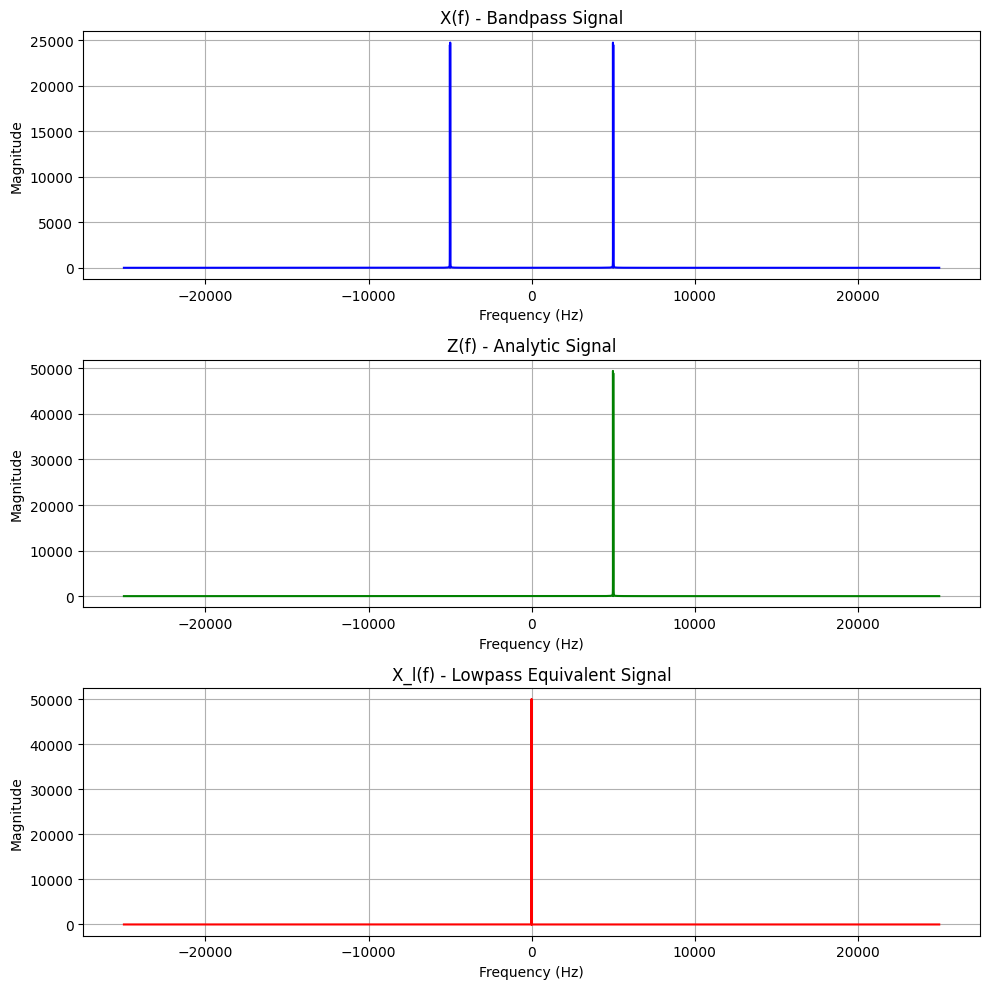

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
# Constants
f0 = 5000  # Center frequency in Hz
f1 = f0 - 10  # Lower frequency in Hz
f2 = f0 + 10  # Higher frequency in Hz
duration = 1  # Duration of the signal in seconds
sampling_rate = 50000  # Sampling rate in Hz
t = np.linspace(0, duration, int(sampling_rate * duration))  # Time vector
# Generate the bandpass signal (two-tone cosine signal)
x_t = np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)
# Compute the analytic signal using the Hilbert transform
z_t = hilbert(x_t)
# Lowpass equivalent signal
x_l_t = z_t * np.exp(-1j * 2 * np.pi * f0 * t)
# Compute the frequency domain representations
def plot_frequency_spectrum(signal, title, ax, color):
    # Compute the FFT of the signal
    n = len(signal)
    freqs = np.fft.fftfreq(n, 1/sampling_rate)
    fft_signal = np.fft.fft(signal)
    
    # Plot the magnitude of the FFT with the specified color
    ax.plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(fft_signal)), color=color)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.grid()
# Create the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
# Plot X(f) - Frequency domain representation of x(t)
plot_frequency_spectrum(x_t, "X(f) - Bandpass Signal", axes[0], color='blue')
# Plot Z(f) - Frequency domain representation of the analytic signal
plot_frequency_spectrum(z_t, "Z(f) - Analytic Signal", axes[1], color='green')
# Plot X_l(f) - Frequency domain representation of the lowpass signal
plot_frequency_spectrum(x_l_t, "X_l(f) - Lowpass Equivalent Signal", axes[2], color='red')
# Display the plots
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info"> 
<h2><center> Report of Laboratory Excercise 2 </center></h2>
<br>

Answer the following questions supporting your claims with formulations and figures obtained from the Student Tasks. Add your codes at the end as appendix.
    
__NOTE:__ You should prepare these questions up to the next laboratory session. Teaching assistants will verify your progress during next session. Final report should be uploaded to Lisam in pdf format according to laboratory session's guidelines. 
    
1. Explain what is an energy- and power-type signal and their characteristics. Is the signal from Student Task 1 a power- or energy-type signal? Why is it called time-average autocorrelation function, and what is the power spectrum? (2pt)
2. What happen at different sampling rates in Student Task 2? What is the aliasing distortion? (2pt)
3. What is the lowpass representation of a bandpass signal? (1pt)
</div>